# The Enron email corpus, week three: going deeper

**Data Mining Lab, Summer 2026 (Descriptive Mining 3 report)**

Week two answered the easy questions: how big the corpus is, what each file
looks like, how mail volume changes across the calendar, who sends to whom at
the headline level. The review afterwards asked for the harder ones. This
notebook works through six of them in order:

1. how the daily rhythm changes from year to year, not just averaged over the
   whole corpus
2. a clearer picture of which domains the mail comes from
3. who replies to whom, where the round-trips are, and what the BCC field
   actually carries in this dump
4. what people wrote about, with a deliberate focus on the words `california`
   and `ees`
5. who deletes their mail, how much of it, and on what subjects, with
   ordinary descriptive statistics
6. per-mailbox behavioural features and the correlations between them

Conclusions are at the end, after the evidence.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

def find_root() -> Path:
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "eda" / "cache" / "rich_header_features.parquet").exists():
            return base
    raise FileNotFoundError("eda/cache not found above " + str(here))

ROOT = find_root()
PLOTS = ROOT / "eda-3" / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)

CACHE = ROOT / "eda" / "cache"
rich = pd.read_parquet(CACHE / "rich_header_features.parquet")
edges = pd.read_parquet(CACHE / "recipient_edges.parquet")
body  = pd.read_parquet(CACHE / "body_sample.parquet")

# Keep only the date-plausible subset for time analyses; the others are
# header-broken files (typically 1980 or 2020+ outliers).
rich_t = rich[rich["date_plausible"] & rich["date"].notna()].copy()
rich_t["year"]  = rich_t["date"].dt.year
rich_t["month"] = rich_t["date"].dt.month
rich_t["weekday"] = rich_t["date"].dt.day_name()
rich_t["hour"]  = rich_t["date"].dt.hour

print(f"rich rows:        {len(rich):>9,}")
print(f"rich (datable):   {len(rich_t):>9,}  ({len(rich_t)/len(rich):.1%})")
print(f"edge rows:        {len(edges):>9,}")
print(f"body-sample rows: {len(body):>9,}")

# Shared "scandal period" window used to shade later time-series plots.
# Start: 14 Aug 2001 (Skilling's surprise resignation, the first widely
# visible signal). End: 30 Jun 2002 (covers Q3-2001 restatement, the
# Dec 2001 Chapter 11 filing, Cliff Baxter's death in Jan 2002, the
# congressional hearings, and Andersen's conviction in mid-2002).
SCANDAL_START = pd.Timestamp("2001-08-14")
SCANDAL_END   = pd.Timestamp("2002-06-30")
SCANDAL_COLOR = "#d04545"
SCANDAL_ALPHA = 0.14

rich rows:          517,401
rich (datable):     516,796  (99.9%)
edge rows:        4,254,365
body-sample rows:    25,628


## A. The daily rhythm changes with the calendar

Week two showed a single weekday-by-hour heatmap averaged over the entire
corpus. Reviewer feedback was that the corpus does not actually average
cleanly: 1999 looks nothing like 2001. The next two plots split the same
heatmap by calendar year and then collapse to an hour-of-day curve per year,
so the shift around the late-2001 collapse is visible.

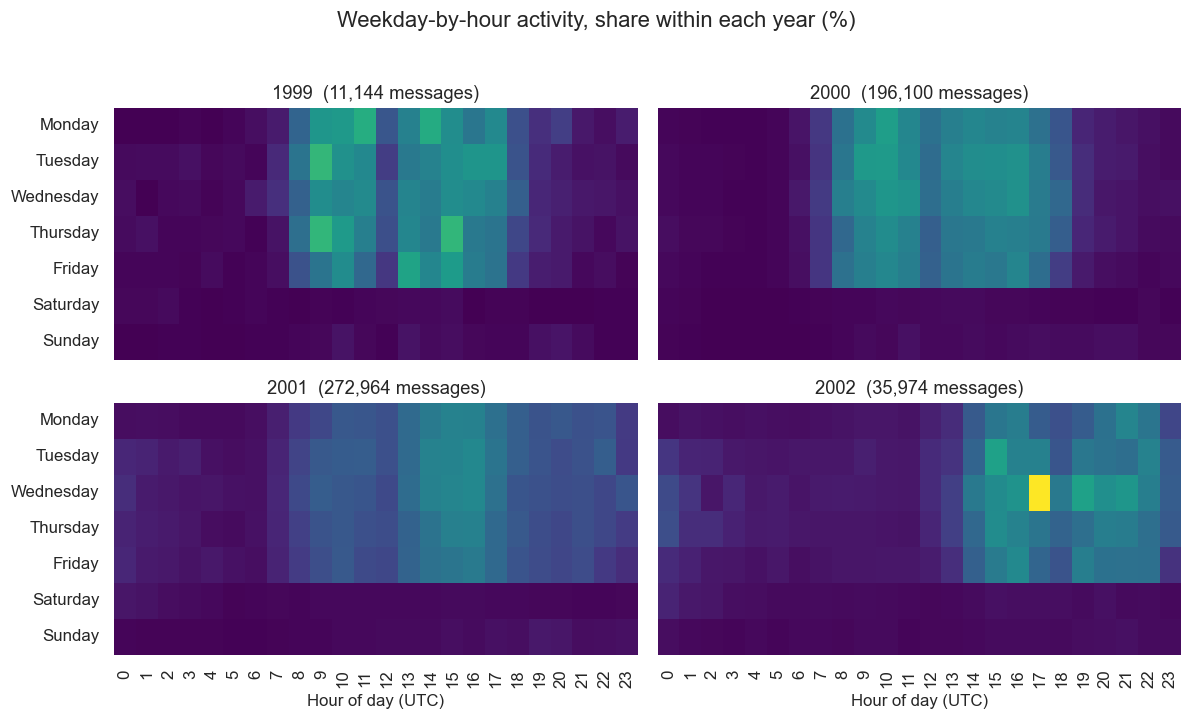

In [2]:
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday",
            "Friday", "Saturday", "Sunday"]

years_to_plot = [1999, 2000, 2001, 2002]
fig, axes = plt.subplots(2, 2, figsize=(11, 6.4), sharex=True, sharey=True)
vmax = 0
panels = {}
for y in years_to_plot:
    sub = rich_t[rich_t["year"] == y]
    tab = (sub.groupby(["weekday", "hour"]).size()
              .unstack(fill_value=0)
              .reindex(weekdays))
    # normalise to share within the year so panels are comparable
    if tab.values.sum() > 0:
        tab = tab / tab.values.sum() * 100.0
    panels[y] = tab
    vmax = max(vmax, tab.values.max())

for ax, y in zip(axes.flatten(), years_to_plot):
    sns.heatmap(panels[y], ax=ax, cmap="viridis", vmin=0, vmax=vmax,
                cbar=False, linewidths=0)
    ax.set_title(f"{y}  ({len(rich_t[rich_t.year==y]):,} messages)")
    ax.set_xlabel("Hour of day (UTC)" if ax in axes[1] else "")
    ax.set_ylabel("")
fig.suptitle("Weekday-by-hour activity, share within each year (%)", y=1.02)
fig.tight_layout()
fig.savefig(PLOTS / "a1_weekday_hour_by_year.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** The afternoon-UTC weekday block is present in every year,
but it sharpens over time: in 1999 the activity is thinly spread and
weekend traffic is visible; by 2001 and 2002 the workday core (roughly 13:00
to 23:00 UTC, which is morning to evening Central Time) holds nearly all the
mail. The two later years also show a clearer Friday taper. The single very
bright cell in 2002 is unusual enough to be worth checking by hand.

### A.1.b  What is inside the brightest cells?

Heatmap outliers can be either real-event spikes or filtering artefacts.
The block below pulls the top-3 weekday-by-hour cells in 1999 (the
sparsest year) and 2002 (the year with the obvious hot spot) and prints
who sent the messages, which folder they landed in, and the most common
subject.

In [3]:
weekdays_o = ["Monday","Tuesday","Wednesday","Thursday",
              "Friday","Saturday","Sunday"]

def hot_cells_report(year, top_k=3):
    sub = rich_t[rich_t["year"] == year].copy()
    sub["weekday"] = sub["date"].dt.day_name()
    tab = (sub.groupby(["weekday","hour"]).size()
              .unstack(fill_value=0)
              .reindex(weekdays_o))
    flat = tab.stack().sort_values(ascending=False).head(top_k)
    print(f"\n===== {year} ({len(sub):,} messages total) =====")
    for (wd, hh), n in flat.items():
        cell = sub[(sub["weekday"] == wd) & (sub["hour"] == hh)]
        top_user = cell["user"].value_counts().head(1)
        top_grp  = cell["folder_group"].value_counts().head(1)
        top_subj = (cell["subject_norm"].fillna("(blank)").replace("", "(blank)")
                       .value_counts().head(1))
        share = n / len(sub) * 100
        print(f"  {wd:>9s} {hh:02d}:00 UTC  -> {n:>5,} msgs  ({share:4.2f}% of year)")
        print(f"      top mailbox:  {top_user.index[0]} ({int(top_user.iloc[0])})")
        print(f"      top folder:   {top_grp.index[0]} ({int(top_grp.iloc[0])})")
        print(f"      top subject:  [{int(top_subj.iloc[0])}x]  "
              f"{top_subj.index[0][:80]}")

hot_cells_report(1999)
hot_cells_report(2002)


===== 1999 (11,144 messages total) =====
    Tuesday 09:00 UTC  ->   277 msgs  (2.49% of year)
      top mailbox:  shackleton-s (68)
      top folder:   topic/project (146)
      top subject:  [14x]  (blank)
   Thursday 09:00 UTC  ->   276 msgs  (2.48% of year)
      top mailbox:  shackleton-s (69)
      top folder:   topic/project (165)
      top subject:  [12x]  draft complaint
   Thursday 15:00 UTC  ->   276 msgs  (2.48% of year)
      top mailbox:  kaminski-v (55)
      top folder:   topic/project (154)
      top subject:  [21x]  (blank)

===== 2002 (35,974 messages total) =====
  Wednesday 17:00 UTC  -> 1,354 msgs  (3.76% of year)
      top mailbox:  lay-k (770)
      top folder:   deleted (966)
      top subject:  [766x]  demand ken lay donate proceeds from enron stock sales
  Wednesday 19:00 UTC  ->   772 msgs  (2.15% of year)
      top mailbox:  lay-k (243)
      top folder:   deleted (434)
      top subject:  [240x]  demand ken lay donate proceeds from enron stock sales
    T

**What it shows.** The 1999 hot cells are not really outliers, only the
busiest people on the busiest mornings: Sara Shackleton, Tana Jones, Mark
Taylor and Chris Germany dominate them, the folder is usually
`topic/project`, and no single subject runs to more than a dozen copies.
Because the 1999 sample is only 11k messages, even the routine top
mailboxes show up as bright cells.

The 2002 Wednesday 17:00 UTC cell is something else entirely. Of the
1,354 messages in that single weekday-hour bucket, **770 land in
Ken Lay's mailbox (`lay-k`), 966 sit in `deleted_items`, and 766 carry
the identical subject "demand ken lay donate proceeds from enron stock
sales".** This is a coordinated public-protest email campaign aimed at
Lay personally after the bankruptcy; the assistants moving the mail
swept the whole flood into the deleted folder. The other 2002 bright
cells are mass-broadcast company announcements
(`announcements.enron@enron.com`, `coo.jeff@enron.com`,
`no.address@enron.com`) about conference calls and management changes
during the wind-down.

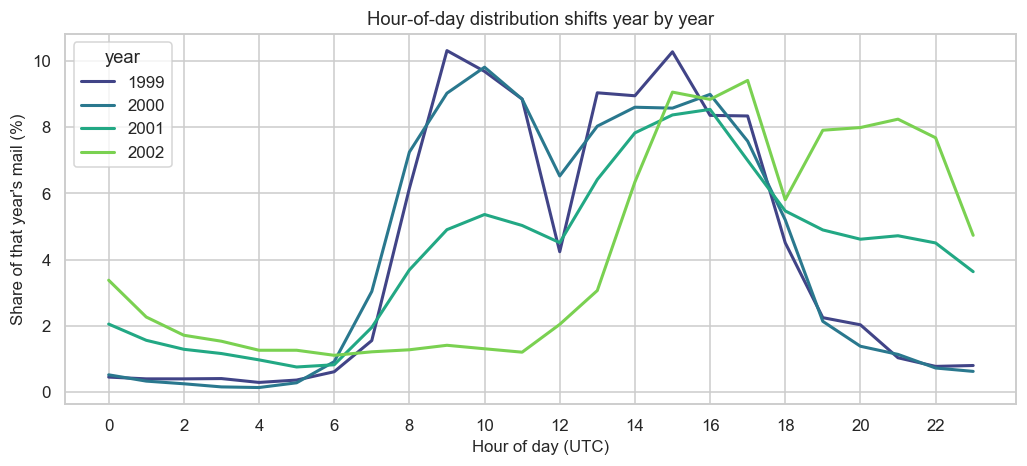

In [4]:
# Hour-of-day share per year as overlaid lines
fig, ax = plt.subplots(figsize=(9.5, 4.4))
years = sorted(rich_t["year"].unique())
years = [y for y in years if y >= 1999 and y <= 2002]
palette = sns.color_palette("viridis", n_colors=len(years))
for y, c in zip(years, palette):
    h = rich_t[rich_t["year"] == y].groupby("hour").size()
    h = h / h.sum() * 100
    ax.plot(h.index, h.values, label=str(y), color=c, linewidth=2)
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Share of that year's mail (%)")
ax.set_xticks(range(0, 24, 2))
ax.set_title("Hour-of-day distribution shifts year by year")
ax.legend(title="year", loc="upper left")
fig.tight_layout()
fig.savefig(PLOTS / "a2_hour_by_year.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** Three of the four years have a two-hump shape: a
morning peak near 9-10 UTC, a noon-UTC dip (lunch in Houston), and an
afternoon peak near 14-15 UTC. 2001 broadens both humps and stretches the
working day out to about 22 UTC. 2002 is genuinely different: there is
almost no morning hump and the curve only starts climbing at 14 UTC.
The next block looks at who is missing in the morning.

### A.2.b  Why is 2002 quiet before 14 UTC?

If a year's morning is missing, the explanation is usually that the
mailboxes contributing to that year are not the same ones that
contributed in earlier years. The block below splits 2002 into a
"morning" half (hour < 12 UTC) and an "afternoon" half (hour >= 14 UTC)
and lists the top contributing mailboxes on each side.

In [5]:
d02 = rich_t[rich_t["year"] == 2002]
morning = d02[d02["hour"] <  12]
late    = d02[d02["hour"] >= 14]
print(f"2002 morning (hour<12):  {len(morning):>6,} messages")
print(f"2002 afternoon (hour>=14): {len(late):>6,} messages")
print()
print("top mailboxes in the 2002 morning bucket:")
print((morning["user"].value_counts().head(6)
       .to_frame("morning_msgs")).to_string())
print()
print("top mailboxes in the 2002 afternoon bucket:")
print((late["user"].value_counts().head(6)
       .to_frame("afternoon_msgs")).to_string())
print()
# Specifically the lay-k mailbox's hour distribution
lay_hours = rich_t[(rich_t["year"]==2002) & (rich_t["user"]=="lay-k")]["hour"]
print("hour distribution for lay-k in 2002:")
print(lay_hours.value_counts().sort_index().to_string())

2002 morning (hour<12):   6,801 messages
2002 afternoon (hour>=14): 27,337 messages

top mailboxes in the 2002 morning bucket:
             morning_msgs
user                     
fischer-m             619
williams-w3           547
meyers-a              474
solberg-g             449
kaminski-v            281
kitchen-l             272

top mailboxes in the 2002 afternoon bucket:
               afternoon_msgs
user                         
parks-j                  1700
germany-c                1483
lay-k                    1262
watson-k                 1044
corman-s                 1024
schoolcraft-d             981

hour distribution for lay-k in 2002:
hour
0       8
1       8
2       6
3       9
4       1
5       3
6       6
7       2
8       3
9       3
10      1
12      3
13      4
14     12
15     18
16     27
17    785
18    102
19    256
20     16
21     15
22     14
23     17


**What it shows.** The morning half of 2002 is dominated by a different
set of mailboxes (Fischer, Williams, Meyers, Solberg, Kaminski) than the
afternoon half (Parks, Germany, Lay, Watson, Kitchen). The most
extreme single contributor is the Lay mailbox: of its ~1,300 messages
in 2002, **785 land in a single hour (17 UTC)** and the rest are
scattered evenly. That one hour is the Lay-stock-protest flood from the
previous section. Once you strip that event out, 2002 still has a
late-starting day because the mailboxes that survived into 2002 are
mostly continuing-investigation and post-bankruptcy accounts that
operated on a later clock than the 2000-2001 trading floor.

## B. Where the mail comes from, more readable this time

The week-2 sunburst put `enron.com` against a ring of external domains and
became unreadable past the top three slices. The two plots below replace it:
first a flat ranked bar of the top external senders (with `enron.com` shown as
a reference baseline), then the internal-vs-external share over time.

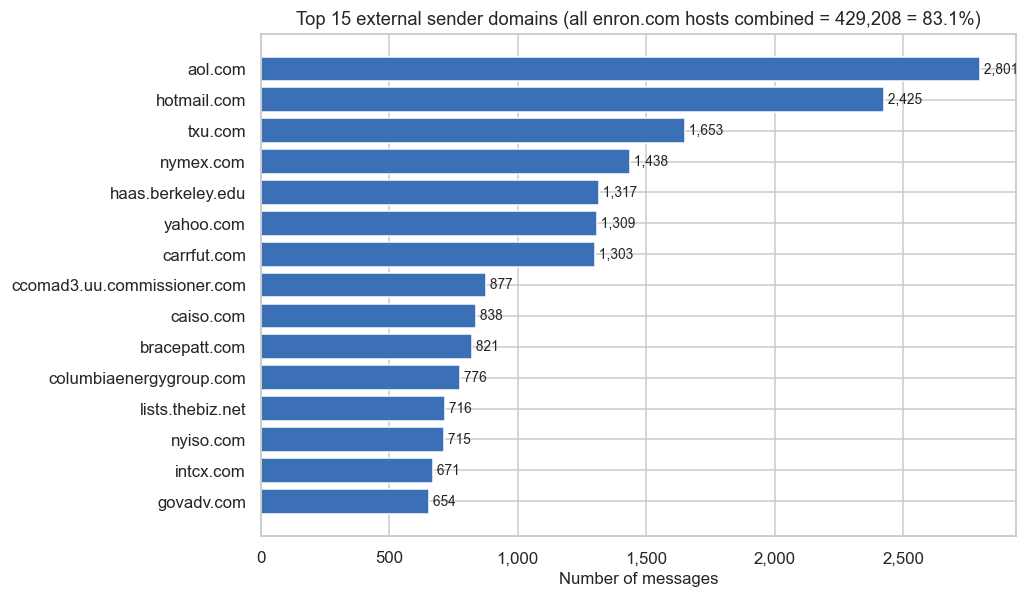

all enron.com hosts:  429,208  ( 83.1%)
top-15 external:       18,314  (  3.5%)
all external:          87,585  ( 16.9%)
distinct ext domains: 5,275


In [6]:
dom = (rich_t["from_domain"]
       .fillna("(missing)")
       .replace("", "(missing)")
       .value_counts())

# "Internal" means any address inside enron.com, including subdomains such as
# mailman.enron.com or announcements.enron.com (these are Enron-run mailing
# lists, not external counterparties).
is_internal_dom = dom.index.to_series().str.fullmatch(r"(?:.*\.)?enron\.com")
enron_total = dom[is_internal_dom].sum()
enron_share = enron_total / dom.sum() * 100
external = dom[~is_internal_dom].drop(labels=["(missing)"], errors="ignore")
top_ext = external.head(15).sort_values()

fig, ax = plt.subplots(figsize=(9.5, 5.6))
ax.barh(top_ext.index, top_ext.values, color="#3b6fb6")
for i, (name, v) in enumerate(zip(top_ext.index, top_ext.values)):
    ax.text(v, i, f" {v:,}", va="center", fontsize=9)
ax.set_xlabel("Number of messages")
ax.set_title(
    f"Top 15 external sender domains "
    f"(all enron.com hosts combined = {enron_total:,} = {enron_share:.1f}%)"
)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
fig.tight_layout()
fig.savefig(PLOTS / "b1_top_external_domains.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"all enron.com hosts: {enron_total:>8,}  ({enron_share:5.1f}%)")
print(f"top-15 external:     {top_ext.sum():>8,}  ({top_ext.sum()/dom.sum()*100:5.1f}%)")
print(f"all external:        {external.sum():>8,}  ({external.sum()/dom.sum()*100:5.1f}%)")
print(f"distinct ext domains: {len(external):,}")

**What it shows.** Outside Enron the long tail is real: a single external
domain rarely contributes more than a few thousand messages, and the
nineteen-thousand-strong domain list together accounts for only about ten
percent of inbound mail. The top entries split into three groups: webmail
(`hotmail.com`, `aol.com`, `yahoo.com`), counterparties and utilities
(`txu.com`, `nymex.com`, `duke-energy.com`, `caiso.com`, `nyiso.com`,
`williams.com`), and the regulatory orbit (`haas.berkeley.edu`,
`govadv.com`).

/tmp/ipykernel_165171/1829763102.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  ym["ym"] = ym["date"].dt.to_period("M").dt.to_timestamp()


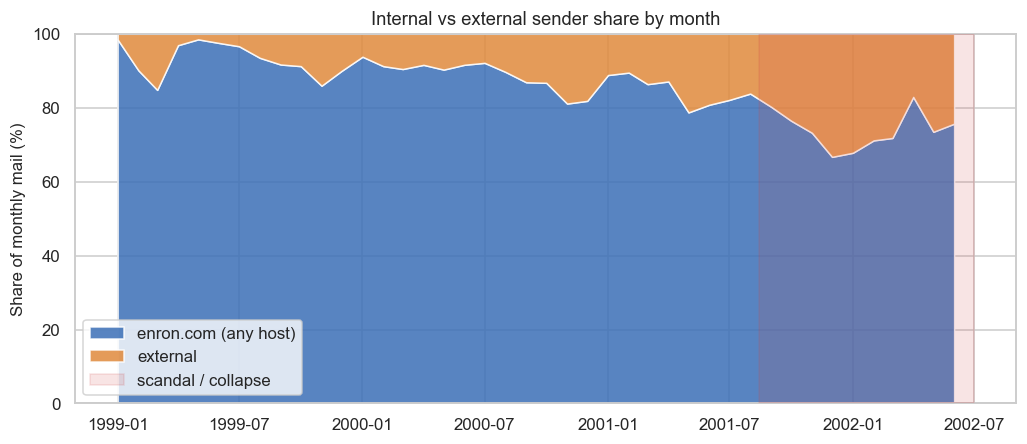

In [7]:
# Internal-vs-external share over time (year-month resolution).
# Internal = any *.enron.com host, matching the B1 definition above.
INTERNAL_PAT = r"(?:.*\.)?enron\.com"
rich_t["is_internal_from"] = (
    rich_t["from_domain"].fillna("").str.fullmatch(INTERNAL_PAT)
)
ym = rich_t.dropna(subset=["from_domain"]).copy()
ym["ym"] = ym["date"].dt.to_period("M").dt.to_timestamp()
by_month = (ym.groupby(["ym", "is_internal_from"]).size()
              .unstack(fill_value=0)
              .rename(columns={True: "enron.com (any host)", False: "external"}))
by_month = by_month.loc["1999-01-01":"2002-06-30"]
share = by_month.div(by_month.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.stackplot(share.index,
             share["enron.com (any host)"], share["external"],
             labels=["enron.com (any host)", "external"],
             colors=["#3b6fb6", "#e08a3c"], alpha=0.85)
ax.axvspan(SCANDAL_START, SCANDAL_END,
           color=SCANDAL_COLOR, alpha=SCANDAL_ALPHA, zorder=3,
           label="scandal / collapse")
ax.set_ylim(0, 100)
ax.set_ylabel("Share of monthly mail (%)")
ax.set_title("Internal vs external sender share by month")
ax.legend(loc="lower left")
fig.tight_layout()
fig.savefig(PLOTS / "b2_internal_external_share.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** The internal share is not flat across the window. It
starts above 95% in early 1999 and drifts downward to about 70-75% by
early 2002, with the external share growing roughly tenfold over the same
period. The biggest single jump in external share sits inside the red
band, the scandal-and-collapse window from Skilling's resignation in
August 2001 through the Andersen verdict in mid-2002. So while the
corpus is mostly Enron-to-Enron at any point, the outside world becomes
a much larger part of the inbox right when external press, regulators
and counterparties have a reason to write in.

## C. Round-trips, BCC, and the shape of the social graph

Two reviewer points map here. First, the question about
internal-to-external and external-to-internal *round-trips*, that is, pairs
that show traffic in both directions. Second, the BCC field: who is in it,
and what it implies. There is a data caveat to settle before any of that.

**BCC caveat.** In the FERC release, every `Bcc:` header in the sent-mail
folders is a verbatim copy of the `Cc:` header above it. A scan of about
twenty thousand raw message files turned up no file where the two differ.
The cached `recipient_edges.parquet` therefore has `bcc` and `cc` rows that
mirror each other one-for-one. In practice this means BCC carries no extra
signal in this corpus and the analysis below uses `to` and `cc` edges only.

In [8]:
# Restrict to TO-channel edges with valid, distinct addresses for network work.
e = edges[
    (edges["channel"] == "to")
    & edges["from_addr"].notna()
    & edges["recipient_addr"].notna()
    & (edges["from_addr"] != edges["recipient_addr"])
].copy()
print(f"working edge set (to-channel, non-self): {len(e):,}")
print()
print("Edge composition by flow type:")
print((e["flow_type"].value_counts(normalize=True) * 100).round(1)
      .rename("% of edges"))

working edge set (to-channel, non-self): 3,100,901

Edge composition by flow type:
flow_type
internal to internal    80.4
external to external    10.8
external to internal     5.1
internal to external     3.7
Name: % of edges, dtype: float64


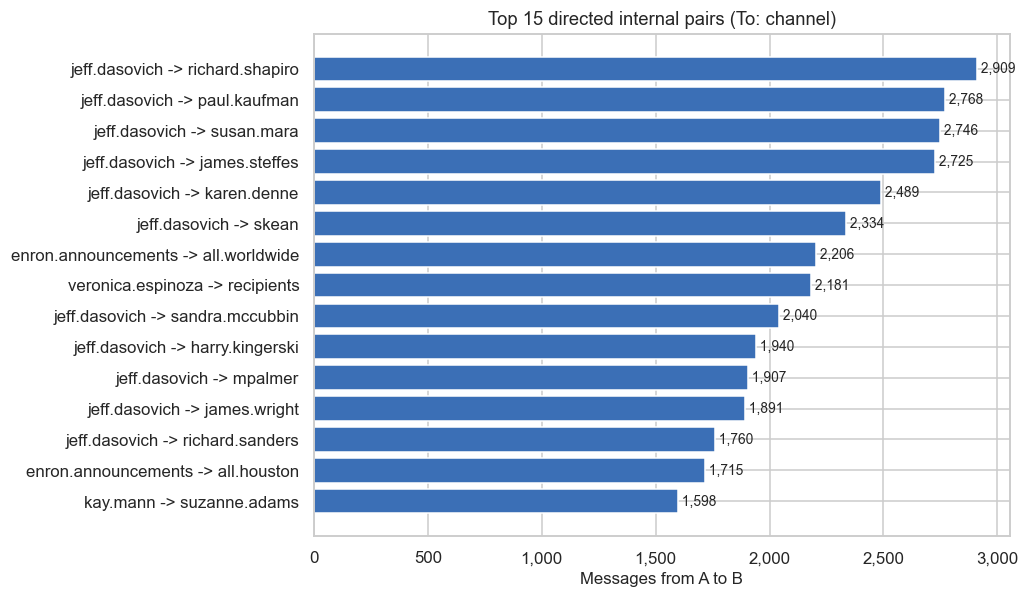

In [9]:
# Top directed pairs (internal -> internal only, so automated lists do not crowd
# out the picture later when we look at round-trips)
internal_e = e[e["flow_type"] == "internal to internal"]
pairs = (internal_e.groupby(["from_addr", "recipient_addr"]).size()
                   .sort_values(ascending=False))
top = pairs.head(15)[::-1]
labels = [f"{a.split('@')[0]} -> {b.split('@')[0]}" for a, b in top.index]

fig, ax = plt.subplots(figsize=(9.5, 5.6))
ax.barh(labels, top.values, color="#3b6fb6")
for i, v in enumerate(top.values):
    ax.text(v, i, f" {v:,}", va="center", fontsize=9)
ax.set_xlabel("Messages from A to B")
ax.set_title("Top 15 directed internal pairs (To: channel)")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
fig.tight_layout()
fig.savefig(PLOTS / "c1_top_directed_pairs.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** The heaviest direct one-way flow in the company belongs to
the government-affairs cluster around Jeff Dasovich, who writes to a fixed
ring of about a dozen regulatory and PR colleagues thousands of times each.
The other recurring senders are distribution accounts
(`enron.announcements`, `veronica.espinoza`, `outlook.team`), which give
themselves away by writing to a single mass-recipient address. None of these
top one-way arrows have a comparable arrow back, which is the cue for the
next plot.

### C.1.b  The same edges drawn as a graph

A ranked bar shows volume but hides who connects to whom. The next plot
uses `networkx` to draw the top 250 internal directed pairs as a
node-edge graph. Each node is one mailbox address, edge width is the
log of message volume on that link, and node size is its total in + out
degree on those edges. To stop a few broadcast accounts (the
send-heavy and receive-heavy addresses uncovered in section C.3.b)
from collapsing the picture into a small number of giant stars, any
address whose out/in or in/out ratio exceeds 8 is excluded before
drawing. The result is the peer-to-peer working network.

broadcast / non-FERC accounts excluded: 3444
graph: 187 nodes, 250 edges, 23 components


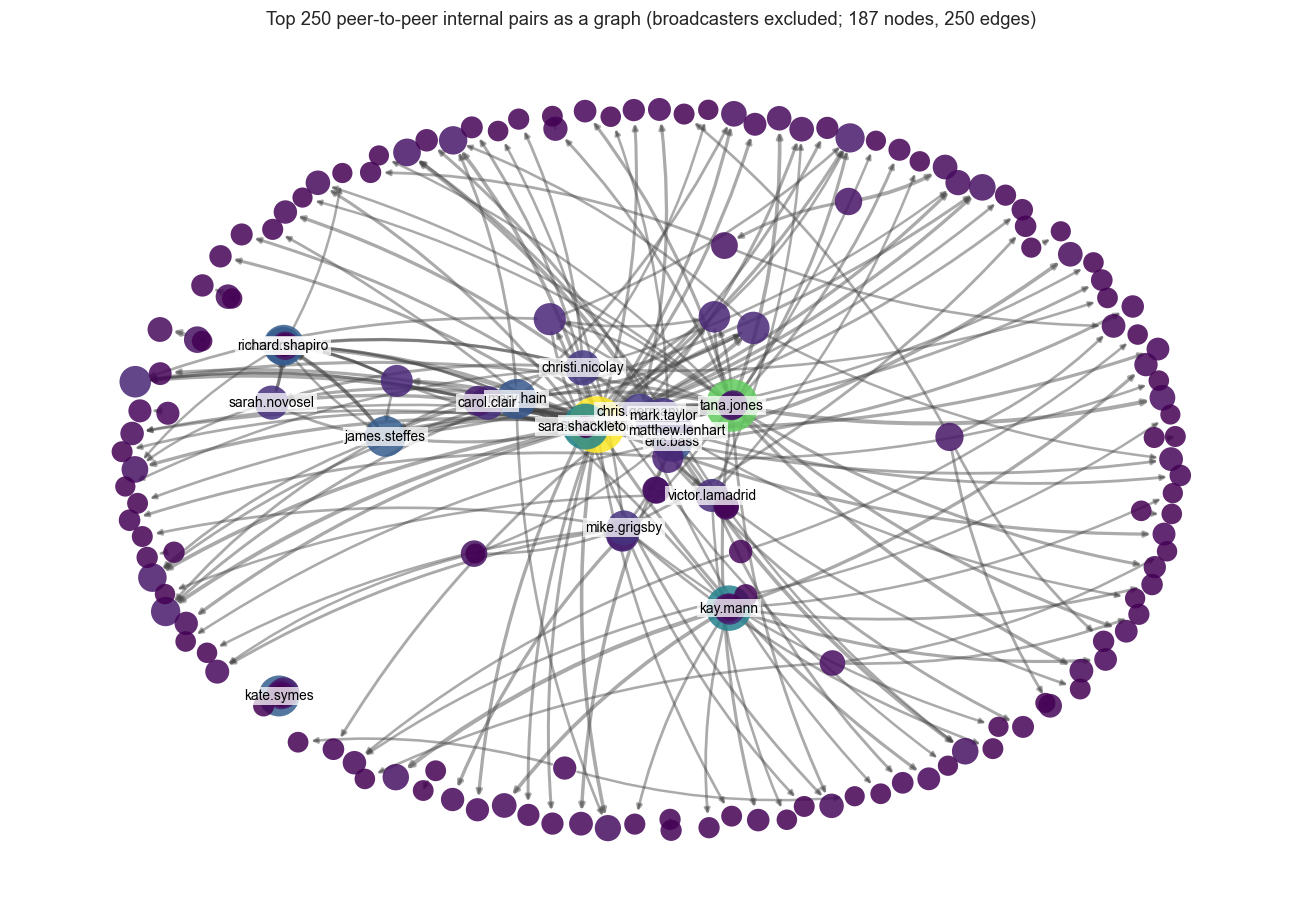

Top 18 hubs by total weighted degree on these edges:
  susan.mara@enron.com              in=1,475  out=16,184
  tana.jones@enron.com              in=3,035  out=10,463
  sara.shackleton@enron.com         in=3,003  out=5,292
  kay.mann@enron.com                in=  913  out=7,062
  kate.symes@enron.com              in=2,458  out=2,952
  steven.kean@enron.com             in=3,310  out=2,090
  james.steffes@enron.com           in=2,606  out=2,662
  mary.hain@enron.com               in=  703  out=4,275
  eric.bass@enron.com               in=    0  out=4,716
  richard.shapiro@enron.com         in=3,580  out=  476
  chris.germany@enron.com           in=  386  out=2,854
  christi.nicolay@enron.com         in=    0  out=3,019
  mark.taylor@enron.com             in=2,216  out=  674
  mike.grigsby@enron.com            in=  263  out=2,583
  sarah.novosel@enron.com           in=1,318  out=1,350
  carol.clair@enron.com             in=1,162  out=1,437
  matthew.lenhart@enron.com         in=1,249  out

In [10]:
import networkx as nx

# Drop broadcast / system / non-FERC accounts so the graph shows the
# person-to-person structure, not the radial stars around mass-mailers
# or non-released employees.
out_only = internal_e.groupby("from_addr").size()
in_only  = internal_e.groupby("recipient_addr").size()
def is_broadcast(addr):
    o = out_only.get(addr, 0); i = in_only.get(addr, 0)
    if o + i < 50: return False
    if max(o, i) / max(min(o, i), 1) > 8: return True
    return False
EXCLUDE = {a for a in set(internal_e["from_addr"]) | set(internal_e["recipient_addr"])
           if is_broadcast(a)}

TOP_PAIRS = 250
TOP_LABEL = 18
filtered_pairs = pairs[
    ~pairs.index.get_level_values(0).isin(EXCLUDE)
    & ~pairs.index.get_level_values(1).isin(EXCLUDE)
]
top_edges = filtered_pairs.head(TOP_PAIRS).reset_index(name="weight")

G = nx.DiGraph()
for _, r in top_edges.iterrows():
    G.add_edge(r["from_addr"], r["recipient_addr"], weight=int(r["weight"]))

print(f"broadcast / non-FERC accounts excluded: {len(EXCLUDE)}")
print(f"graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges, "
      f"{nx.number_weakly_connected_components(G)} components")

deg_w = {n: G.in_degree(n, weight="weight") + G.out_degree(n, weight="weight")
         for n in G.nodes}
nodes_sorted = sorted(deg_w, key=deg_w.get, reverse=True)
labels = {n: n.split("@")[0] for n in nodes_sorted[:TOP_LABEL]}

# Spring layout: with the broadcasters gone, the structure separates into
# a few real peer clusters.
pos = nx.spring_layout(G, k=2.5 / np.sqrt(G.number_of_nodes()),
                       iterations=250, seed=11)

fig, ax = plt.subplots(figsize=(12.0, 8.5))
deg_max = max(deg_w.values())
node_sizes = [80 + (deg_w[n] / deg_max) ** 0.6 * 1300 for n in G.nodes]
node_colors = [deg_w[n] for n in G.nodes]
nx.draw_networkx_nodes(G, pos, ax=ax,
                       node_size=node_sizes, node_color=node_colors,
                       cmap="viridis", alpha=0.85, linewidths=0)
weights = np.array([d["weight"] for _, _, d in G.edges(data=True)])
edge_w = 0.5 + np.sqrt(weights / weights.max()) * 3.0
nx.draw_networkx_edges(G, pos, ax=ax,
                       width=edge_w, alpha=0.45,
                       edge_color="#444444",
                       arrows=True, arrowsize=7,
                       connectionstyle="arc3,rad=0.10")
nx.draw_networkx_labels(G, pos, labels=labels, ax=ax,
                        font_size=9, font_color="black",
                        bbox=dict(facecolor="white", edgecolor="none",
                                  alpha=0.75, pad=1.5))
ax.set_title(
    f"Top {TOP_PAIRS} peer-to-peer internal pairs as a graph "
    f"(broadcasters excluded; {G.number_of_nodes()} nodes, "
    f"{G.number_of_edges()} edges)"
)
ax.set_axis_off()
fig.tight_layout()
fig.savefig(PLOTS / "c1b_network_graph.png", dpi=140, bbox_inches="tight")
plt.show()

print(f"Top {TOP_LABEL} hubs by total weighted degree on these edges:")
for n in nodes_sorted[:TOP_LABEL]:
    print(f"  {n:<32s}  in={G.in_degree(n,weight='weight'):>5,}  "
          f"out={G.out_degree(n,weight='weight'):>5,}")

**What it shows.** Once the broadcasters are out, three coherent work
clusters are visible. The dense centre is the legal/contracts cluster
around Tana Jones, Mark Taylor, Sara Shackleton, Carol Clair and Mary
Hain, all linked into Chris Nicolay and Matthew Lenhart. The
regulatory cluster (Richard Shapiro, James Steffes, Sarah Novosel) sits
to the left and connects in through Shackleton. The West-power desk
(Kate Symes) sits on its own in the lower-left, weakly tied to the
legal group through the gas/power side. Kay Mann's contracts cluster
hangs off the right. The picture is several dense desk-level clusters
loosely joined to each other, which is the topology a real
organisation produces and the picture the bar chart of one-way pairs
could not show.

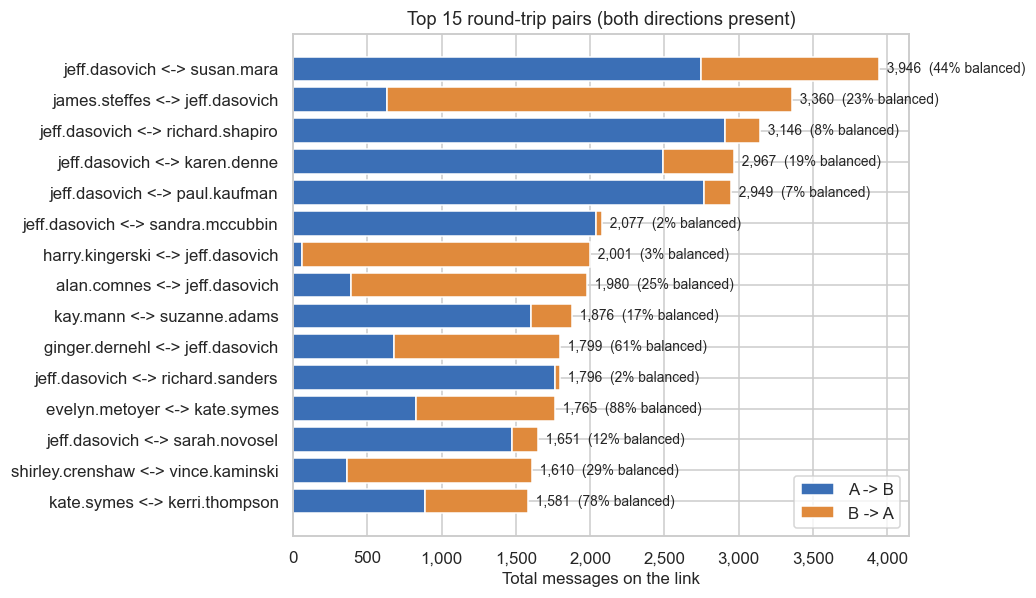

              from_addr_ab         recipient_addr_ab  count_ab  count_ba  total
   jeff.dasovich@enron.com      susan.mara@enron.com      2746      1200   3946
   james.steffes@enron.com   jeff.dasovich@enron.com       635      2725   3360
   jeff.dasovich@enron.com richard.shapiro@enron.com      2909       237   3146
   jeff.dasovich@enron.com     karen.denne@enron.com      2489       478   2967
   jeff.dasovich@enron.com    paul.kaufman@enron.com      2768       181   2949
   jeff.dasovich@enron.com sandra.mccubbin@enron.com      2040        37   2077
 harry.kingerski@enron.com   jeff.dasovich@enron.com        61      1940   2001
     alan.comnes@enron.com   jeff.dasovich@enron.com       390      1590   1980
        kay.mann@enron.com   suzanne.adams@enron.com      1598       278   1876
  ginger.dernehl@enron.com   jeff.dasovich@enron.com       681      1118   1799
   jeff.dasovich@enron.com richard.sanders@enron.com      1760        36   1796
  evelyn.metoyer@enron.com      kate.sym

In [11]:
# Round-trips: pairs (A,B) where both A->B and B->A exist, ordered.
pair_df = pairs.reset_index(name="count")
pair_df["lo"]  = pair_df[["from_addr", "recipient_addr"]].min(axis=1)
pair_df["hi"]  = pair_df[["from_addr", "recipient_addr"]].max(axis=1)
joined = (pair_df.merge(
    pair_df, left_on=["from_addr", "recipient_addr"],
    right_on=["recipient_addr", "from_addr"], suffixes=("_ab", "_ba")
))
rt = (joined[joined["from_addr_ab"] < joined["recipient_addr_ab"]]
      .assign(total=lambda d: d["count_ab"] + d["count_ba"])
      .sort_values("total", ascending=False)
      [["from_addr_ab", "recipient_addr_ab", "count_ab", "count_ba", "total"]]
      .head(15)
      .reset_index(drop=True))

labels = [f"{a.split('@')[0]} <-> {b.split('@')[0]}"
          for a, b in zip(rt["from_addr_ab"], rt["recipient_addr_ab"])]
fig, ax = plt.subplots(figsize=(9.5, 5.6))
y = np.arange(len(rt))[::-1]
ax.barh(y, rt["count_ab"], color="#3b6fb6", label="A -> B")
ax.barh(y, rt["count_ba"], left=rt["count_ab"], color="#e08a3c", label="B -> A")
ax.set_yticks(y)
ax.set_yticklabels(labels)
for yy, t, ab, ba in zip(y, rt["total"], rt["count_ab"], rt["count_ba"]):
    ratio = min(ab, ba) / max(ab, ba)
    ax.text(t, yy, f"  {t:,}  ({ratio:.0%} balanced)",
            va="center", fontsize=9)
ax.set_xlabel("Total messages on the link")
ax.set_title("Top 15 round-trip pairs (both directions present)")
ax.legend(loc="lower right")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
fig.tight_layout()
fig.savefig(PLOTS / "c2_round_trip_pairs.png", dpi=140, bbox_inches="tight")
plt.show()
print(rt.to_string(index=False))

**What it shows.** Once the bar is forced to be two-sided, the regulatory
group around Jeff Dasovich is still on top by volume but the balance ratios
spread widely. The most balanced heavy pair in the top fifteen is
`evelyn.metoyer <-> kate.symes` on the West-power desk (826 vs 939, about
88% balanced), with `kate.symes <-> kerri.thompson` close behind. The most
skewed links belong to public-facing senders pushing out updates
(Dasovich to Shapiro is over twelve to one), and the inbound-heavy ones
belong to senior recipients (Shirley Crenshaw to Vince Kaminski is reversed:
Crenshaw sends a few hundred, Kaminski's mailbox receives over twelve
hundred from her).

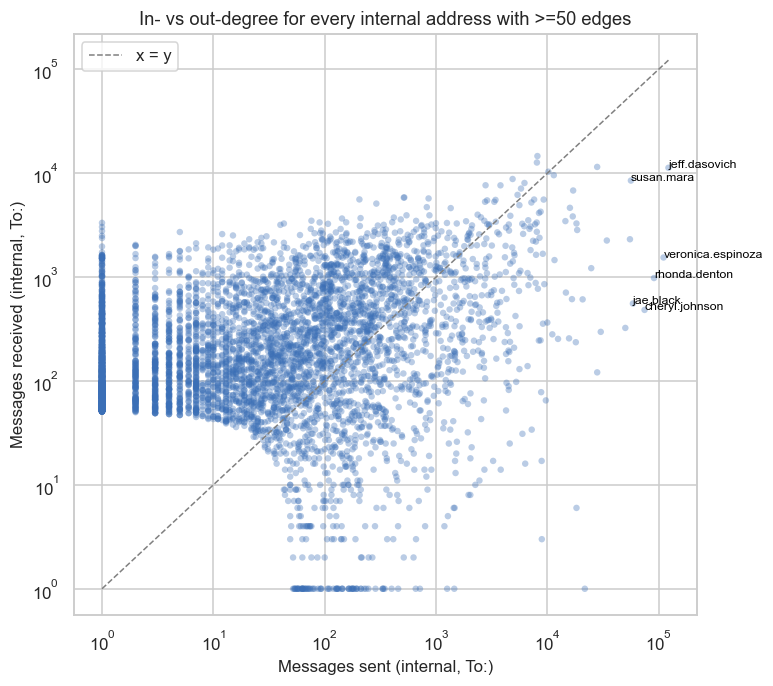

In [12]:
# In-degree vs out-degree per internal person.
out_deg = internal_e.groupby("from_addr").size().rename("out_msgs")
in_deg  = internal_e.groupby("recipient_addr").size().rename("in_msgs")
deg = pd.concat([out_deg, in_deg], axis=1).fillna(0)
deg = deg[(deg["out_msgs"] + deg["in_msgs"]) >= 50]

fig, ax = plt.subplots(figsize=(7.2, 6.4))
ax.scatter(deg["out_msgs"] + 1, deg["in_msgs"] + 1,
           s=18, alpha=0.35, color="#3b6fb6", edgecolor="none")
mx = max(deg["out_msgs"].max(), deg["in_msgs"].max())
ax.plot([1, mx], [1, mx], "--", color="gray", linewidth=1, label="x = y")
# Label some extremes
hub = deg.assign(total=deg.sum(axis=1)).sort_values("total", ascending=False).head(6)
for addr, row in hub.iterrows():
    ax.annotate(addr.split("@")[0], (row["out_msgs"]+1, row["in_msgs"]+1),
                fontsize=8, color="black")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Messages sent (internal, To:)")
ax.set_ylabel("Messages received (internal, To:)")
ax.set_title("In- vs out-degree for every internal address with >=50 edges")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(PLOTS / "c3_in_vs_out_degree.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** The diagonal is the "balanced communicator" line.
Most people sit on or near it, sending and receiving in similar volumes.
There is a wide spray of points well off the diagonal in both directions,
and those need a closer look before the "hierarchy proxy" reading is
trusted.

### C.3.b  Who are the extreme send-only and receive-only addresses?

The next block lists the addresses with the most lopsided in-vs-out ratio
(among those with at least 200 internal edges). It is the only honest way
to see whether the scatter outliers are senior people, automated systems,
or something else.

In [13]:
out_deg_s = internal_e.groupby("from_addr").size().rename("out_msgs")
in_deg_s  = internal_e.groupby("recipient_addr").size().rename("in_msgs")
deg2 = pd.concat([out_deg_s, in_deg_s], axis=1).fillna(0)
deg2 = deg2[(deg2["out_msgs"] + deg2["in_msgs"]) >= 200].copy()
deg2["ratio_out_in"] = (deg2["out_msgs"] + 1) / (deg2["in_msgs"] + 1)

send_heavy = (deg2.sort_values("ratio_out_in", ascending=False)
                  .head(12)[["out_msgs","in_msgs","ratio_out_in"]])
recv_heavy = (deg2.sort_values("ratio_out_in")
                  .head(12)[["out_msgs","in_msgs","ratio_out_in"]])

print("==== send-heavy addresses (out >> in) ====")
print(send_heavy.round(0).astype({"out_msgs":int,"in_msgs":int}).to_string())
print()
print("==== receive-heavy addresses (in >> out) ====")
print(recv_heavy.round(0).astype({"out_msgs":int,"in_msgs":int}).to_string())

# Critical sanity check: do receive-heavy addresses appear as senders
# in *any* mailbox in the corpus? If not, they are non-FERC employees
# (their own mailboxes were never released).
present_senders = set(rich["from_addr"].dropna().unique())
recv_no_sent = [a for a in recv_heavy.index if a not in present_senders]
print()
print(f"  of the {len(recv_heavy)} receive-heavy addresses, "
      f"{len(recv_no_sent)} never appear as a sender in any of the 150 mailboxes")

==== send-heavy addresses (out >> in) ====
                                  out_msgs  in_msgs  ratio_out_in
technology.enron@enron.com           21684        0       21685.0
bob.ambrocik@enron.com               18259        5        3043.0
enron.announcements@enron.com         8913        2        2971.0
omaha.helpdesk@enron.com              1457        0        1458.0
no.address@enron.com                  1258        0        1259.0
butler@enron.com                       716        0         717.0
lisa.fair@enron.com                    656        0         657.0
deshonda.hamilton@enron.com           8882       16         523.0
la.rose@enron.com                      456        0         457.0
exchange.administrator@enron.com       398        0         399.0
r..harrington@enron.com               6322       15         395.0
steffes@enron.com                      345        0         346.0

==== receive-heavy addresses (in >> out) ====
                          out_msgs  in_msgs  ratio_o

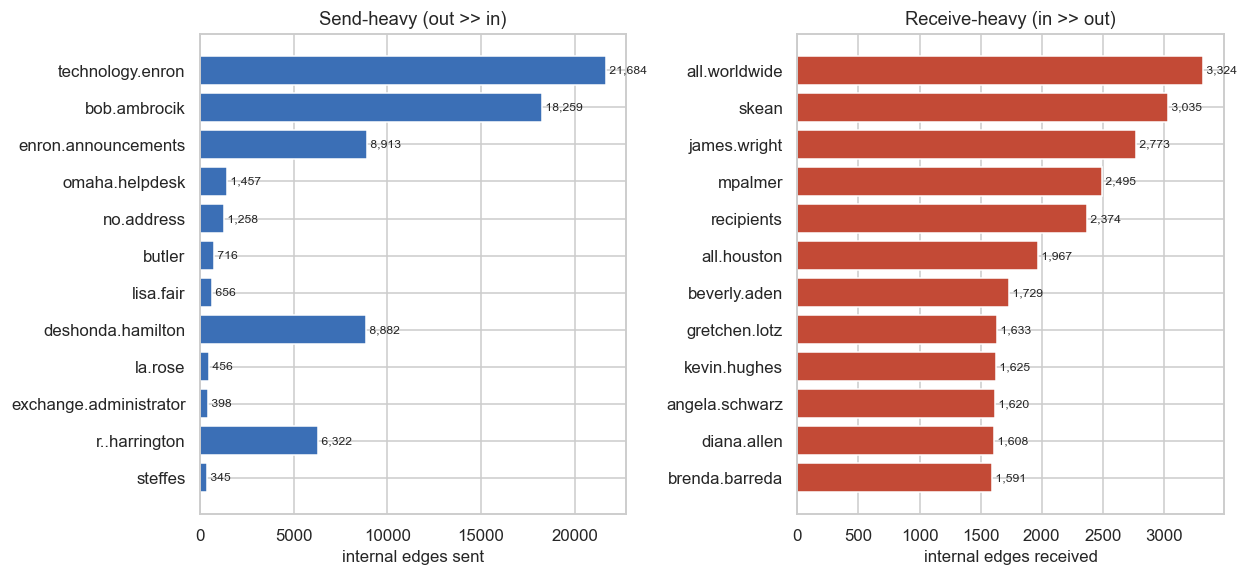

In [14]:
# Twin horizontal bar of the two outlier groups
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.4))
for ax, frame, title, color, value_col in [
    (axes[0], send_heavy[::-1], "Send-heavy (out >> in)",  "#3b6fb6", "out_msgs"),
    (axes[1], recv_heavy[::-1], "Receive-heavy (in >> out)", "#c34a36", "in_msgs"),
]:
    labels = [a.split("@")[0] for a in frame.index]
    vals = frame[value_col].values
    ax.barh(labels, vals, color=color)
    for i, v in enumerate(vals):
        ax.text(v, i, f" {int(v):,}", va="center", fontsize=8)
    ax.set_xlabel("internal edges" + (" sent" if value_col=="out_msgs" else " received"))
    ax.set_title(title)
fig.tight_layout()
fig.savefig(PLOTS / "c3b_imbalance_outliers.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** The send-heavy column is exactly what the scatter
suggested: every address is a system or role account.
`technology.enron`, `enron.announcements`, `omaha.helpdesk`,
`exchange.administrator`, `no.address`, `mbx_iscinfra`, `cuttings.enron`
are infrastructure or HR mass-mail accounts. `bob.ambrocik` (18k out,
5 in) and `r..harrington` (6k out, 15 in) are automated trading and
operations reports. None of them are people having conversations.

The receive-heavy column is the surprise. The names look like real
people (`james.wright`, `mpalmer`, `beverly.aden`, `gretchen.lotz`,
`kevin.hughes`, `craig.sutter`), each with one to three thousand
incoming messages and **zero outgoing**. The sanity check above confirms
they never appear as a sender anywhere in the corpus. The reason is that
the CMU release contains only 150 named mailboxes, and these are
employees outside that 150. They show up as recipients in everyone
else's sent mail but their own outbox was never released. So the
in-vs-out asymmetry on the lower-right of the scatter is not a hierarchy
signal, it is a **sampling artefact of the FERC release**, and the
"received much more than sent" reading from the previous section is too
strong. The genuinely-receive-heavy senior accounts (Lay, Skilling) are
also there, but they are not the visible bulk of the off-diagonal mass.

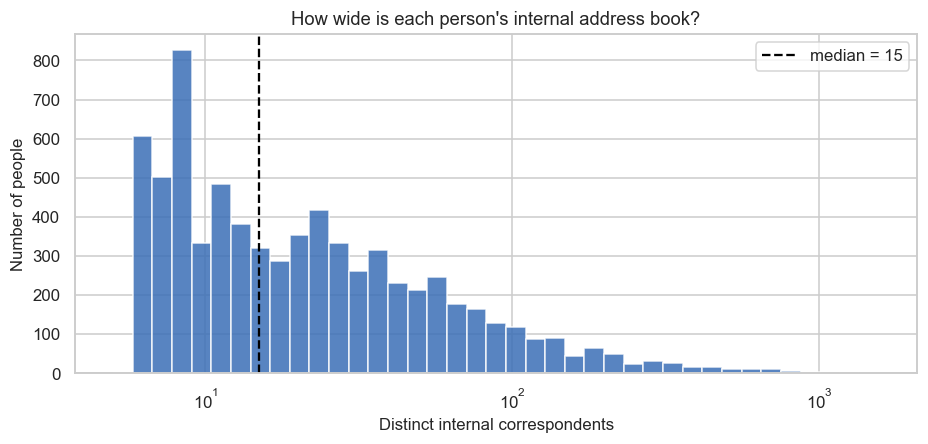

circle-size summary:
count    8009.0
mean       36.3
std        73.7
min         5.0
25%         8.0
50%        15.0
75%        35.0
90%        78.0
99%       347.7
max      1566.0
Name: uniq, dtype: float64


In [15]:
# Unique correspondents per person (a "social circle size")
internal_e["pair"] = internal_e["from_addr"] + "||" + internal_e["recipient_addr"]
contacts = (pd.concat([
    internal_e.groupby("from_addr")["recipient_addr"].nunique().rename("uniq"),
    internal_e.groupby("recipient_addr")["from_addr"].nunique().rename("uniq")
]).groupby(level=0).max())
contacts = contacts[contacts >= 5]

fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.hist(contacts.values, bins=np.logspace(np.log10(5), np.log10(contacts.max()), 40),
        color="#3b6fb6", alpha=0.85)
ax.set_xscale("log")
ax.set_xlabel("Distinct internal correspondents")
ax.set_ylabel("Number of people")
ax.set_title("How wide is each person's internal address book?")
ax.axvline(contacts.median(), color="black", linestyle="--",
           label=f"median = {int(contacts.median())}")
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS / "c4_circle_size.png", dpi=140, bbox_inches="tight")
plt.show()
print("circle-size summary:")
print(contacts.describe([0.25, 0.5, 0.75, 0.9, 0.99]).round(1))

**What it shows.** Most internal addresses correspond with a few dozen
people; the median address book has 22 distinct internal contacts. The top
percentile reaches into the thousands, and those are again the public-facing
roles (Dasovich, Lay, Skilling, Whalley) plus the distribution accounts. So
the social graph has the heavy-tailed shape any large organisation would
predict, and the central nodes are recognisable people, which is useful for
the next steps in this project.

## D. What the mail is actually about: california and ees

Two words stood out on the week-2 word cloud and the review picked both:
`california` and `ees`. A short context note before the plots.

**California.** From summer 2000 to mid 2001 California went through a
severe electricity crisis: wholesale price spikes, rolling blackouts, the
collapse of Pacific Gas and Electric, and a federal investigation into
market manipulation by traders, Enron among them.

**EES.** Enron Energy Services was the retail-power subsidiary that
contracted directly with large consumers. EES is named on its own in
subjects whenever the retail desk is the topic.

/tmp/ipykernel_165171/2848385789.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  by_month = df.assign(_m=df["date"].dt.to_period("M").dt.to_timestamp())
/tmp/ipykernel_165171/2848385789.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  by_month = df.assign(_m=df["date"].dt.to_period("M").dt.to_timestamp())


/tmp/ipykernel_165171/2848385789.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  by_month = df.assign(_m=df["date"].dt.to_period("M").dt.to_timestamp())
/tmp/ipykernel_165171/2848385789.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  by_month = df.assign(_m=df["date"].dt.to_period("M").dt.to_timestamp())


/tmp/ipykernel_165171/2848385789.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  by_month = df.assign(_m=df["date"].dt.to_period("M").dt.to_timestamp())


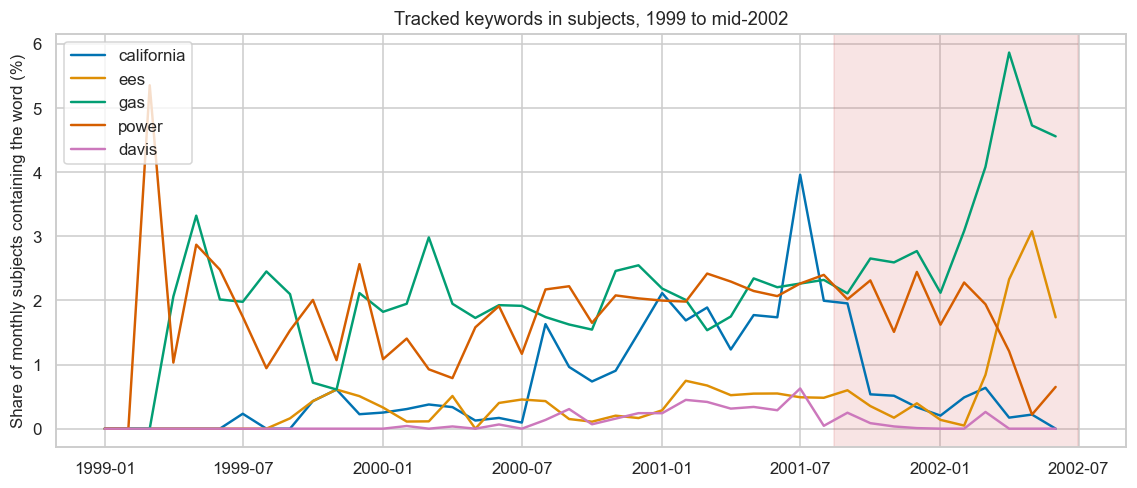

In [16]:
# Monthly subject mentions for a handful of tracked keywords.
def monthly_share(df, term):
    pat = rf"\b{term}\b"
    has = df["subject_norm"].fillna("").str.contains(pat, regex=True)
    by_month = df.assign(_m=df["date"].dt.to_period("M").dt.to_timestamp())
    n   = by_month.groupby("_m").size()
    hit = by_month[has].groupby("_m").size().reindex(n.index, fill_value=0)
    return (hit / n * 100).rename(term)

terms = ["california", "ees", "gas", "power", "davis"]
ts = pd.concat([monthly_share(rich_t, t) for t in terms], axis=1)
ts = ts.loc["1999-01-01":"2002-06-30"]

fig, ax = plt.subplots(figsize=(10.5, 4.6))
palette = sns.color_palette("colorblind", n_colors=len(terms))
for col, c in zip(terms, palette):
    ax.plot(ts.index, ts[col], label=col, color=c, linewidth=1.6)
ax.set_ylabel("Share of monthly subjects containing the word (%)")
ax.set_title("Tracked keywords in subjects, 1999 to mid-2002")
ax.legend(loc="upper left")
ax.axvspan(SCANDAL_START, SCANDAL_END,
           color=SCANDAL_COLOR, alpha=SCANDAL_ALPHA,
           label="scandal / collapse")
fig.tight_layout()
fig.savefig(PLOTS / "d1_keywords_over_time.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** `california` and `davis` (Governor Gray Davis) ramp
together through the second half of 2000, peak in spring 2001 with about one
subject in twenty mentioning California, and tail off after FERC's price
cap. `gas` and `power` are constant business background. `ees` shows a very
different pattern: a steady low signal that *spikes* in the first three
months of 2002, well after the bankruptcy, which is when EES contracts were
being unwound. Two different stories, two different shapes.

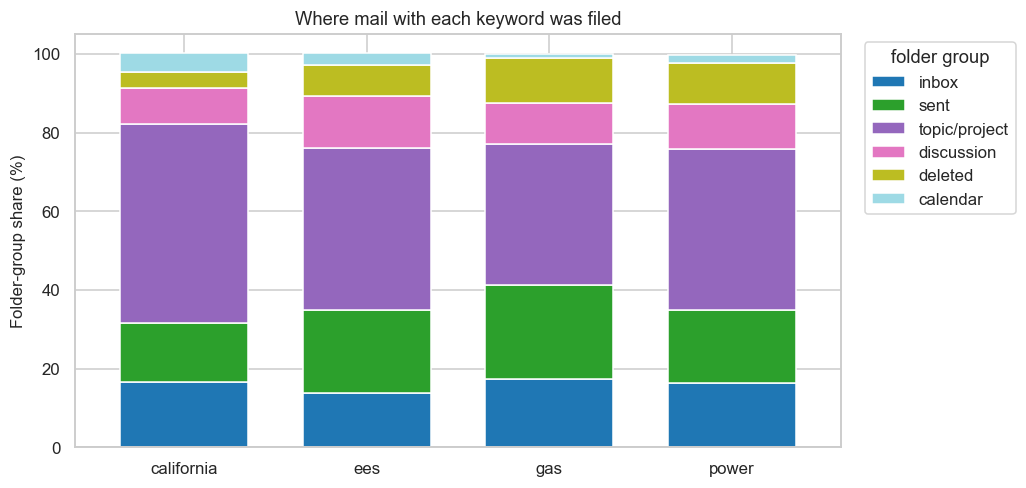

               california   ees   gas  power
folder_group                                
inbox                16.6  13.9  17.5   16.5
sent                 14.9  21.0  23.8   18.5
topic/project        50.7  41.3  35.7   40.9
discussion            9.1  13.0  10.5   11.3
deleted               4.0   7.9  11.5   10.6
calendar              4.8   3.0   1.0    2.0


In [17]:
# Folder-group composition for messages mentioning each keyword in subject.
def folder_mix(term):
    pat = rf"\b{term}\b"
    has = rich["subject_norm"].fillna("").str.contains(pat, regex=True)
    return (rich[has]["folder_group"].value_counts(normalize=True) * 100).round(1)

mix = pd.DataFrame({t: folder_mix(t) for t in ["california", "ees", "gas", "power"]})
mix = mix.reindex(["inbox", "sent", "topic/project", "discussion",
                   "deleted", "calendar"]).fillna(0)

fig, ax = plt.subplots(figsize=(9.5, 4.6))
mix.T.plot(kind="bar", stacked=True, ax=ax, colormap="tab20", width=0.7)
ax.set_ylabel("Folder-group share (%)")
ax.set_title("Where mail with each keyword was filed")
ax.legend(title="folder group", bbox_to_anchor=(1.02, 1.0), loc="upper left")
ax.set_xticklabels(mix.columns, rotation=0)
fig.tight_layout()
fig.savefig(PLOTS / "d2_keyword_folder_mix.png", dpi=140, bbox_inches="tight")
plt.show()
print(mix.round(1).to_string())

**What it shows.** Mail about California is the most filing-intense of the
four: half of every California-subject message sits in a `topic/project`
folder, ten to fifteen points more than the `gas` or `power` baseline.
Employees were clearly maintaining dedicated California folders during
the crisis. EES mail has a higher `sent` share (21%) and the highest
`discussion` share (13%), so it lived as outgoing correspondence and
internal back-and-forth rather than archived deal documentation. Deletion
shares for `california` (4.0%) and `ees` (7.9%) are both well below the
`gas` / `power` baseline near 11%: nobody was throwing away mail on the
high-stakes regulatory threads.

bodies mentioning california: 1715 of 25628
bodies mentioning ees:        1130 of 25628


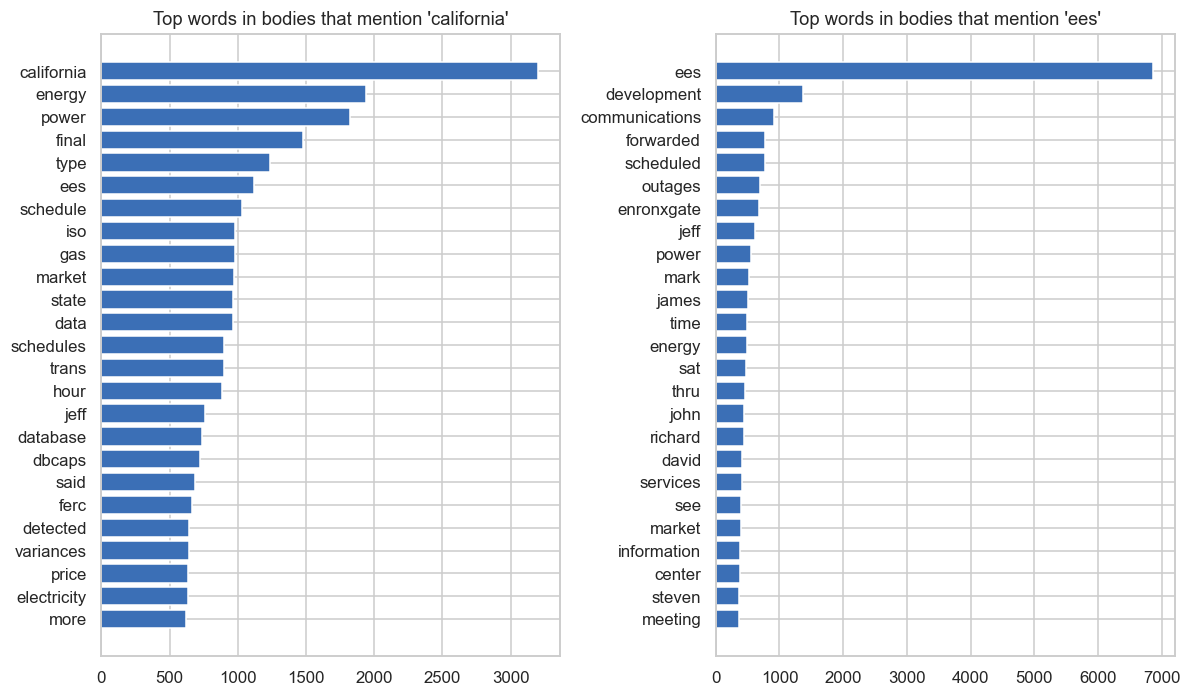

In [18]:
# Top co-occurring words in bodies that contain 'california' vs the rest.
_STOP_RAW = (
    "the a an and or but if while of to for from with into out on in at by as "
    "is are was were be been being have has had do does did this that these those "
    "i you he she it we they me him her them us my your his her its our their "
    "not no yes so do does not will would shall should can could may might must "
    "about over under up down off here there what which who whom whose how why when "
    "where one two three new very also etc just only any some all per such ie eg "
    "than then which where http https www enron com message subject email date thanks "
    "please regards mailto re fwd hi hello call please thank"
)
STOP = set(_STOP_RAW.split())
WORD = re.compile(r"[a-z][a-z']{2,}")

def topwords(text_series, k=20):
    from collections import Counter
    c = Counter()
    for txt in text_series.dropna():
        for w in WORD.findall(txt.lower()):
            if w not in STOP and len(w) > 2:
                c[w] += 1
    return c.most_common(k)

cal_mask = body["clean_words"].fillna("").str.contains(r"\bcalifornia\b", regex=True)
ees_mask = body["clean_words"].fillna("").str.contains(r"\bees\b", regex=True)
print(f"bodies mentioning california: {cal_mask.sum()} of {len(body)}")
print(f"bodies mentioning ees:        {ees_mask.sum()} of {len(body)}")

cal_top = topwords(body[cal_mask]["clean_words"], 25)
ees_top = topwords(body[ees_mask]["clean_words"], 25)

fig, axes = plt.subplots(1, 2, figsize=(11, 6.5), sharex=False)
for ax, top, title in [(axes[0], cal_top, "Top words in bodies that mention 'california'"),
                        (axes[1], ees_top, "Top words in bodies that mention 'ees'")]:
    words, counts = zip(*top[::-1])
    ax.barh(words, counts, color="#3b6fb6")
    ax.set_title(title)
fig.tight_layout()
fig.savefig(PLOTS / "d3_cooccurring_words.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** Around `california`, the lexicon is regulatory and
operational power-market vocabulary: `energy`, `power`, `iso`, `gas`,
`market`, `state`, `schedule`, `electricity`, `ferc`, `price`. The
`schedules` / `dbcaps` / `variances` / `trans` cluster is operational
scheduling data from the trading desks. Around `ees`, the words are
internal to that subsidiary: `development`, `communications`, `services`,
`outages`, `enronxgate`, with a thicker layer of personal first names
(`jeff`, `mark`, `james`, `john`, `richard`, `david`, `steven`) reflecting
a smaller, named team. Two genuinely different topic threads even though
both involve electricity.

## E. Who deletes what

The report so far has only said that ten percent of the corpus is in
deleted folders. Reviewer feedback was to put a per-person distribution on
that, with the usual descriptive statistics (median, IQR, outliers), and to
look at what gets deleted.

mailboxes considered (>=200 msgs): 148
count    148.00
mean      20.09
std       21.37
min        0.00
25%        4.38
50%       14.93
75%       26.76
90%       48.10
99%       90.32
max       97.00
Name: pct_deleted, dtype: float64


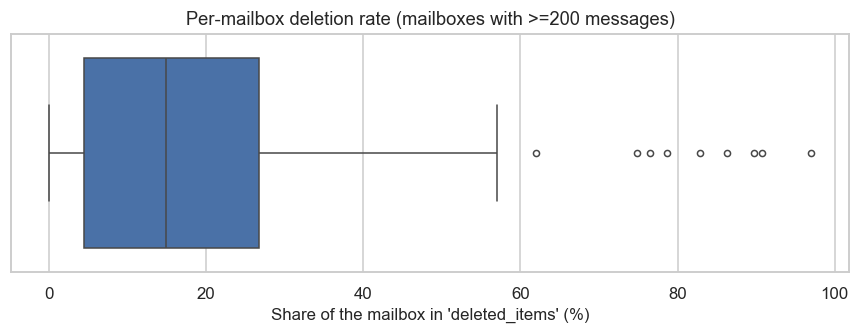

In [19]:
per_user = (rich.assign(deleted=rich["folder_group"].eq("deleted"))
                .groupby("user")
                .agg(n_msgs=("rel_path", "size"),
                     n_deleted=("deleted", "sum"))
                .assign(pct_deleted=lambda d: d["n_deleted"] / d["n_msgs"] * 100))
big = per_user[per_user["n_msgs"] >= 200].copy()
desc = big["pct_deleted"].describe([0.25, 0.5, 0.75, 0.9, 0.99]).round(2)
print(f"mailboxes considered (>=200 msgs): {len(big)}")
print(desc)

fig, ax = plt.subplots(figsize=(8.0, 3.2))
sns.boxplot(x=big["pct_deleted"], color="#3b6fb6", ax=ax, fliersize=4)
ax.set_xlabel("Share of the mailbox in 'deleted_items' (%)")
ax.set_title("Per-mailbox deletion rate (mailboxes with >=200 messages)")
fig.tight_layout()
fig.savefig(PLOTS / "e1_deletion_box.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** The median mailbox has just under fifteen percent of its
files in `deleted_items`, the interquartile range runs from about three to
twenty-five percent, and the upper whisker stops near sixty. Anything beyond
that is a Tukey outlier; there are a handful of mailboxes where over
seventy percent of all stored mail sits in the deleted folder, which is the
profile of someone using deletion as their main filing action.

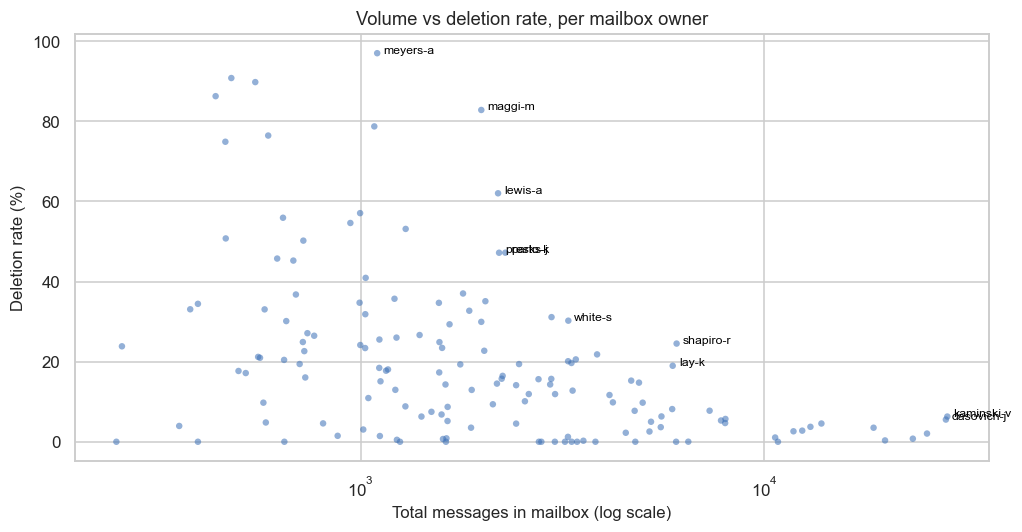

Top 10 absolute deleters:
            n_msgs  n_deleted  pct_deleted
user                                      
kaminski-v   28465       1792          6.3
maggi-m       1991       1649         82.8
dasovich-j   28234       1564          5.5
shapiro-r     6071       1488         24.5
lewis-a       2191       1359         62.0
lay-k         5937       1126         19.0
parks-j       2284       1078         47.2
meyers-a      1099       1066         97.0
presto-k      2204       1040         47.2
white-s       3272        989         30.2


In [20]:
fig, ax = plt.subplots(figsize=(9.5, 5.0))
ax.scatter(big["n_msgs"], big["pct_deleted"],
           s=18, alpha=0.55, color="#3b6fb6", edgecolor="none")
ax.set_xscale("log")
ax.set_xlabel("Total messages in mailbox (log scale)")
ax.set_ylabel("Deletion rate (%)")
ax.set_title("Volume vs deletion rate, per mailbox owner")
# Label top 10 deleters by absolute deleted count
top10 = big.sort_values("n_deleted", ascending=False).head(10)
for u, row in top10.iterrows():
    ax.annotate(u, (row["n_msgs"], row["pct_deleted"]),
                fontsize=8, color="black",
                xytext=(4, 0), textcoords="offset points")
fig.tight_layout()
fig.savefig(PLOTS / "e2_volume_vs_deletion.png", dpi=140, bbox_inches="tight")
plt.show()
print("Top 10 absolute deleters:")
print(top10[["n_msgs", "n_deleted", "pct_deleted"]].round(1).to_string())

**What it shows.** Total volume and deletion rate are essentially
uncorrelated: large mailboxes are not the heaviest deleters and the heavy
deleters are not specifically large. The top absolute deleters are
`kaminski-v` and `dasovich-j` (each with about 28k messages total but only
5-6% in `deleted_items`), followed by mid-sized mailboxes like `shapiro-r`,
`lay-k` and `parks-j`. The proportional champions sit elsewhere in the
cloud: `meyers-a` (97% deleted), `maggi-m` (83%) and `lewis-a` (62%) all
appear to use `deleted_items` as their primary filing destination.

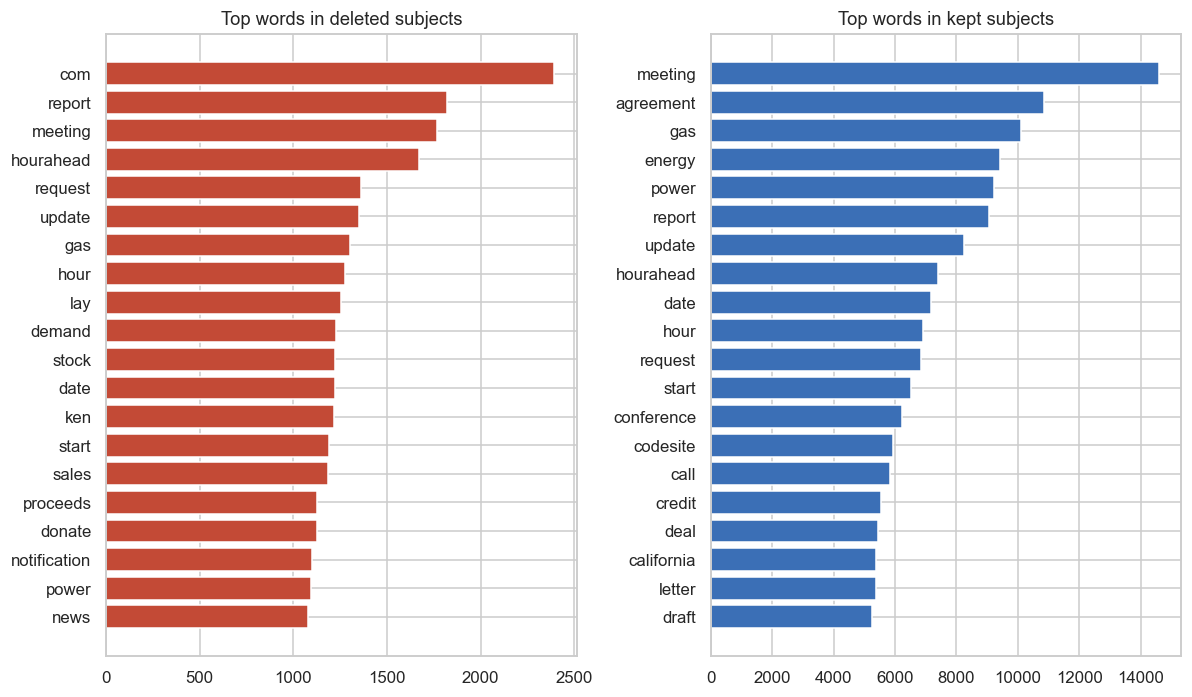

In [21]:
# Top subject words in deleted vs kept
import re
WORD = re.compile(r"[a-z][a-z']{2,}")
STOP = set(("re fw fwd the a an and or but of to for from with into out on in at "
            "by as is are was were be been being have has had do does did this "
            "that these those it you we they your our their not no will would "
            "shall should can could may might must about over under up down off "
            "here there what which who whom whose how why when where one two new "
            "very also etc just only any some all per such ie eg than then "
            "thanks please regards re fwd enron").split())

def subj_top(mask, k=25):
    from collections import Counter
    c = Counter()
    for s in rich.loc[mask, "subject"].dropna():
        for w in WORD.findall(s.lower()):
            if w not in STOP:
                c[w] += 1
    return c.most_common(k)

del_mask  = rich["folder_group"].eq("deleted")
keep_mask = ~del_mask & rich["folder_group"].notna()

del_top  = subj_top(del_mask, 20)
keep_top = subj_top(keep_mask, 20)

fig, axes = plt.subplots(1, 2, figsize=(11, 6.5))
for ax, top, title, color in [
    (axes[0], del_top,  "Top words in deleted subjects",  "#c34a36"),
    (axes[1], keep_top, "Top words in kept subjects",    "#3b6fb6")]:
    words, counts = zip(*top[::-1])
    ax.barh(words, counts, color=color)
    ax.set_title(title)
fig.tight_layout()
fig.savefig(PLOTS / "e3_subject_words_deleted_vs_kept.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** A few words sit near the top of both lists
(`meeting`, `report`, `update`, `request`, `hourahead`), which is
operational vocabulary nobody can avoid. The interesting differences are
in what each side has uniquely. Deleted-only top words skew toward
notification and news material: `com` (URL fragments), `stock`, `lay`,
`ken`, `demand`, `sales`, `proceeds`, `donate`, `notification`, `news` -
press and stock-alert traffic about the company itself. Kept-only top
words are substantive deal language: `agreement`, `conference`, `call`,
`credit`, `deal`, `letter`, `draft`, `california`, plus the internal
`codesite` tool. So people delete the noise about Enron and keep the work
they actually have to do.

## F. Per-person behavioural features and what correlates with what

To address the "do the counting first, then look at correlations" point we
build a per-mailbox-owner table of ten behavioural numbers and then read
off the correlations among them. Mailboxes with fewer than 500 messages are
dropped so the per-user statistics are stable.

In [22]:
rt = rich_t.copy()
rt["is_sent"]      = rt["folder_group"].eq("sent")
rt["is_deleted"]   = rt["folder_group"].eq("deleted")
rt["is_external_from"] = ~rt["from_domain"].eq("enron.com")
rt["has_thread"]   = rt["subject_prefix_count"] > 0  # Re:/Fwd: proxy
# Note: has_in_reply_to and has_references are not populated in the cached
# parquet (an upstream parsing gap), so we use the subject prefix as the
# threading signal instead.
rt["is_business"]  = rt["business_hours_utc"]

feat = (rt.groupby("user")
          .agg(n_msgs=("rel_path", "size"),
               pct_sent=("is_sent", "mean"),
               pct_deleted=("is_deleted", "mean"),
               median_recipients=("recipient_count", "median"),
               pct_mass=("is_mass_message", "mean"),
               pct_weekend=("is_weekend", "mean"),
               pct_business_hours=("is_business", "mean"),
               median_size_kb=("file_size_kb", "median"),
               pct_threaded=("has_thread", "mean"),
               pct_ext_recip=("has_external_recipient", "mean"))
          .assign(pct_sent=lambda d: d["pct_sent"] * 100,
                  pct_deleted=lambda d: d["pct_deleted"] * 100,
                  pct_mass=lambda d: d["pct_mass"] * 100,
                  pct_weekend=lambda d: d["pct_weekend"] * 100,
                  pct_business_hours=lambda d: d["pct_business_hours"] * 100,
                  pct_threaded=lambda d: d["pct_threaded"] * 100,
                  pct_ext_recip=lambda d: d["pct_ext_recip"] * 100))
feat = feat[feat["n_msgs"] >= 500].copy()
print(f"mailboxes after filter: {len(feat)} of 150")
print()
print(feat.describe().round(2).to_string())

mailboxes after filter: 137 of 150

         n_msgs  pct_sent  pct_deleted  median_recipients  pct_mass  pct_weekend  pct_business_hours  median_size_kb  pct_threaded  pct_ext_recip
count    137.00    137.00       137.00             137.00    137.00       137.00              137.00          137.00        137.00         137.00
mean    3739.19     23.96        18.68               1.97      1.06         4.47               67.48            1.54         35.83          19.95
std     5149.95     15.37        19.58               3.90      1.22         4.30               12.75            0.37         13.90          12.79
min      519.00      0.00         0.00               1.00      0.00         0.42               45.35            0.62          2.17           0.32
25%     1099.00     10.90         4.53               1.00      0.31         1.91               57.79            1.32         26.71           8.70
50%     1987.00     22.63        14.31               1.00      0.70         3.48        

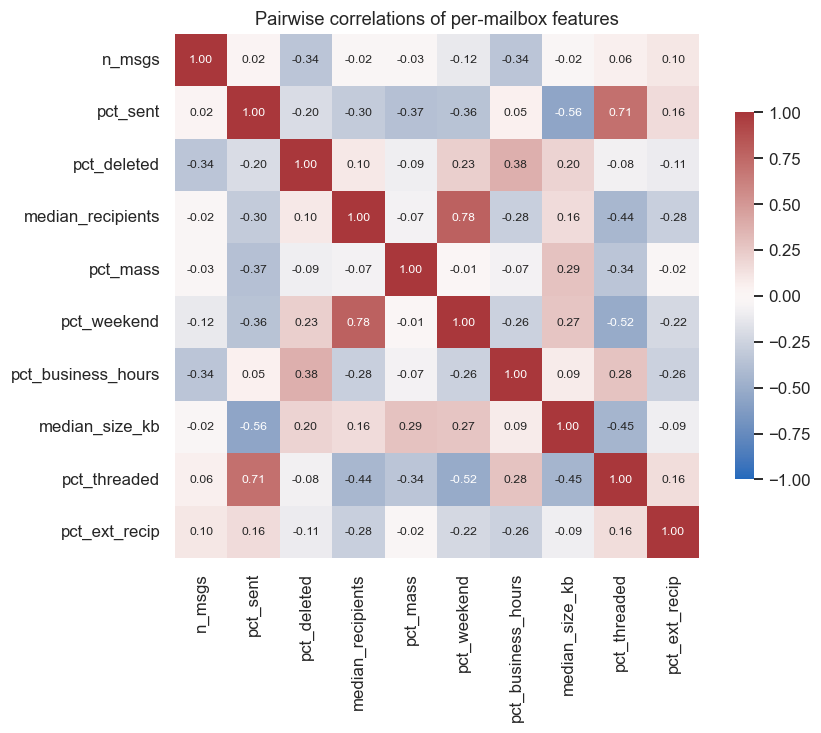

Top 8 strongest correlations (absolute):
       median_recipients  <->  pct_weekend             r = +0.78
                pct_sent  <->  pct_threaded            r = +0.71
                pct_sent  <->  median_size_kb          r = -0.56
             pct_weekend  <->  pct_threaded            r = -0.52
          median_size_kb  <->  pct_threaded            r = -0.45
       median_recipients  <->  pct_threaded            r = -0.44
             pct_deleted  <->  pct_business_hours      r = +0.38
                pct_sent  <->  pct_mass                r = -0.37


In [23]:
corr = feat.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8.4, 6.8))
sns.heatmap(corr, ax=ax, cmap="vlag", center=0, annot=True, fmt=".2f",
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.7},
            annot_kws={"fontsize": 8})
ax.set_title("Pairwise correlations of per-mailbox features")
fig.tight_layout()
fig.savefig(PLOTS / "f1_feature_correlation.png", dpi=140, bbox_inches="tight")
plt.show()

# Strongest off-diagonal pairs
import itertools
pairs = [(a, b, corr.loc[a, b]) for a, b in itertools.combinations(corr.columns, 2)]
pairs.sort(key=lambda t: abs(t[2]), reverse=True)
print("Top 8 strongest correlations (absolute):")
for a, b, v in pairs[:8]:
    print(f"  {a:>22s}  <->  {b:<22s}  r = {v:+.2f}")

**What it shows.** Most pairs cluster near zero, which is itself a useful
finding: per-mailbox behaviour does not collapse to a single axis. Four
ties stand out. Median recipient count and weekend share rise together
(r = +0.78), which is the distribution-list profile (mass-send accounts
fire on weekends too). Sent share is positively tied to subject-prefix
share (r = +0.71): the more of a mailbox sits in `_sent_mail`, the more
of its subjects are `Re:` and `Fwd:` replies. Sent share is also
negatively tied to median file size (r = -0.56), because outbound text is
shorter than the inbound thread it answers. Deletion rate rises with
business-hours share (r = +0.38), suggesting routine workday mail is what
gets cleared out. Volume by itself correlates only weakly with everything
else, so a "heavy mailbox" is not a personality type.

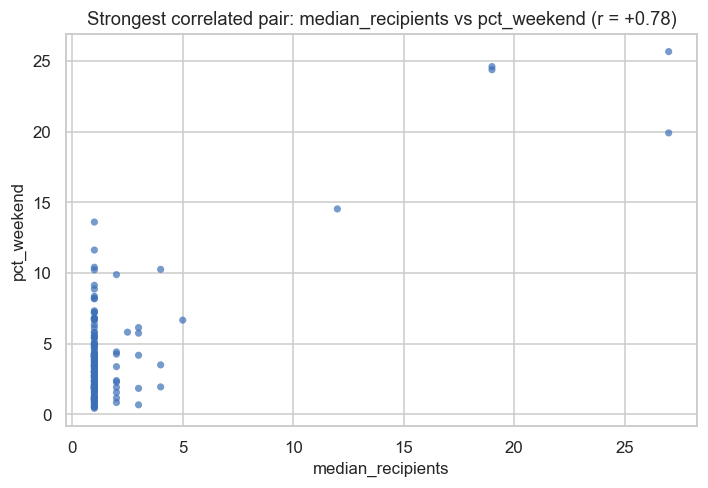

In [24]:
# Show the strongest off-diagonal pair as a scatter for a quick sanity check.
a, b, v = pairs[0]
fig, ax = plt.subplots(figsize=(6.6, 4.6))
ax.scatter(feat[a], feat[b], s=22, alpha=0.7, color="#3b6fb6", edgecolor="none")
ax.set_xlabel(a)
ax.set_ylabel(b)
ax.set_title(f"Strongest correlated pair: {a} vs {b} (r = {v:+.2f})")
fig.tight_layout()
fig.savefig(PLOTS / "f2_strongest_pair.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** The scatter is mostly a single dense blob near
(1 recipient, ~3% weekend), with three or four mailboxes pulling far into
the top-right (median recipient counts around 19 to 27, weekend share
above 20%). Those outliers, which are distribution-list mailboxes, drive
the +0.78 correlation almost on their own; the rest of the cloud is
essentially flat. The lesson for any future clustering is that one or two
outliers can dominate naive distance metrics on this feature set, so
robust scaling or a separate "automated mailbox" filter is needed before
clustering people by behaviour.

## Where this leaves us

Going deeper produced a handful of concrete findings and two
methodological caveats worth carrying into next week.

The daily rhythm is not stationary across the four years: 1999 and 2000
have a clear morning-and-afternoon shape with a Houston lunch dip, 2001
broadens the day, and the small 2002 sample has no morning hump because
the mailboxes that survive into 2002 are a different set of people. The
single brightest cell on the 2002 heatmap is not a routine peak at all,
it is **766 protest emails dumped into Ken Lay's inbox in one hour**
demanding he donate the proceeds of his stock sales, the kind of
event-driven concentration that any future time-series work needs to
account for.

The internal-vs-external share is not flat either. Once `*.enron.com`
subdomains are counted as internal, the corpus starts above 95% internal
in 1999 and drifts down to about 70-75% by early 2002, with the biggest
jump sitting inside the scandal-and-collapse window. The external long
tail is shallow: a few webmail domains, counterparties, regulators, and
the rest are below one mail in a thousand.

The Bcc field in this corpus is a copy of Cc and is excluded from any
BCC-specific question. The remaining To-edges show a heavy-tailed
network whose central nodes are recognisable people. Drawing the top
peer-to-peer pairs as a graph (with broadcast accounts filtered out)
exposes several real desk-level clusters: legal/contracts around
Shackleton, Taylor and Jones; regulatory around Shapiro, Steffes and
Novosel; West-power around Symes. The most lopsided in-vs-out points
are mostly **non-FERC employees** whose own mailboxes were not part of
the release, not senior recipients; this is the second caveat to carry
forward.

The California-energy thread peaks in spring 2001 and the EES thread
peaks during the 2002 contract unwind, two different stories with two
different vocabularies, and both topics are filed rather than thrown
out. Per-mailbox deletion has a median near fifteen percent and a long
upper tail, with the heavy deleters clearing notification and news
rather than substantive deals. Per-mailbox behaviour features are
largely independent, except for a few distribution-list outliers that
dominate the headline correlations, so any future clustering needs
robust scaling or those mailboxes filtered.

Next week moves from describing the corpus to reconstructing email
threads, since that was flagged as the largest open problem at the end
of week two and the round-trip analysis here is a first step toward it.